In [42]:
import pandas as pd
x = [1,2,2,3,4,4,5,6]
y = [2,3,4,4,4,6,5,7]

d = {"y":y, "x":x}
df = pd.DataFrame(d)
df

,y,x
0,2,1
1,3,2
2,4,2
3,4,3
4,4,4
5,6,4
6,5,5
7,7,6


In [43]:
import numpy as np
df2=df.copy()
df2["y"]=np.ones(len(df))
df2

,y,x
0,1.0,1
1,1.0,2
2,1.0,2
3,1.0,3
4,1.0,4
5,1.0,4
6,1.0,5
7,1.0,6


In [44]:
X=np.array(df2)
X

array([[1., 1.],
       [1., 2.],
       [1., 2.],
       [1., 3.],
       [1., 4.],
       [1., 4.],
       [1., 5.],
       [1., 6.]])

In [45]:
Xt = X.T
Xt

array([[1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 2., 2., 3., 4., 4., 5., 6.]])

In [46]:
M=Xt@X
M

array([[  8.,  27.],
       [ 27., 111.]])

In [47]:
y=np.array(df[["y"]])
y

array([[2],
       [3],
       [4],
       [4],
       [4],
       [6],
       [5],
       [7]])

In [48]:
detM = np.linalg.det(M)
detM

np.float64(159.0)

In [49]:
inversa=np.linalg.inv(M)
inversa


array([[ 0.69811321, -0.16981132],
       [-0.16981132,  0.05031447]])

In [50]:
pinversa=np.linalg.pinv(M)
pinversa

array([[ 0.69811321, -0.16981132],
       [-0.16981132,  0.05031447]])

In [51]:
betas = inversa @ Xt @ y
betas

array([[1.50943396],
       [0.8490566 ]])

# Mas rapido:

Ver este link relacionado con la matriz pseudo inversa de Moore-Penrose:

https://chatgpt.com/share/68c0df00-15d8-800f-9b6b-61b0a212a247

In [52]:
import pandas as pd
x = [1,2,2,3,4,4,5,6]
y = [2,3,4,4,4,6,5,7]

d = {"x":x, "y":y}
df = pd.DataFrame(d)
df

,x,y
0,1,2
1,2,3
2,2,4
3,3,4
4,4,4
5,4,6
6,5,5
7,6,7


In [53]:
df2=df.copy()
df2["y"]=np.ones(len(df))
df2

,x,y
0,1,1.0
1,2,1.0
2,2,1.0
3,3,1.0
4,4,1.0
5,4,1.0
6,5,1.0
7,6,1.0


In [54]:
X=np.array(df2)
X.shape

(8, 2)

In [55]:
Xpinv= np.linalg.pinv(X)
Xpinv.shape

(2, 8)

In [56]:
y = np.array(df[["y"]])
y.shape

(8, 1)

In [57]:
betas = Xpinv @ y
print(betas.shape)
betas

(2, 1)


array([[0.8490566 ],
       [1.50943396]])

# Ojo la pseudo inversa de Moore-Penrose ya incluye todo (matrices no tienen que ser cuadradas y el det(AtA) puede ser cero)
(la inversa no lo hace directamente pues la matriz debe ser cuadrada, y si fuera cuadrada su det debe ser distinto de cero, ver mas abajo):

In [58]:
Xinv= np.linalg.inv(X)
Xinv.shape

LinAlgError: Last 2 dimensions of the array must be square

# Cálculo de Errores (manualmente)

In [59]:
df["ypred"] = X @ betas
df

,x,y,ypred
0,1,2,2.358491
1,2,3,3.207547
2,2,4,3.207547
3,3,4,4.056604
4,4,4,4.905660
5,4,6,4.905660
6,5,5,5.754717
7,6,7,6.603774


In [60]:
# error = y - ypred
df["y-ypred"] =  df["y"] - df["ypred"]
df

,x,y,ypred,y-ypred
0,1,2,2.358491,-0.358491
1,2,3,3.207547,-0.207547
2,2,4,3.207547,0.792453
3,3,4,4.056604,-0.056604
4,4,4,4.905660,-0.905660
5,4,6,4.905660,1.094340
6,5,5,5.754717,-0.754717
7,6,7,6.603774,0.396226


In [66]:
# error = y - ypred
df["error^2"] = df["y-ypred"]**2
df

,x,y,ypred,y-ypred,error^2
0,1,2,2.358491,-0.358491,0.128515
1,2,3,3.207547,-0.207547,0.043076
2,2,4,3.207547,0.792453,0.627981
3,3,4,4.056604,-0.056604,0.003204
4,4,4,4.905660,-0.905660,0.820221
5,4,6,4.905660,1.094340,1.197579
6,5,5,5.754717,-0.754717,0.569598
7,6,7,6.603774,0.396226,0.156995


In [ ]:
error_cuad_total = df["error^2"].sum()
error_cuad_total

In [63]:
# MSE = error_cuad_medio
mse = error_cuad_total / len(df)
mse

np.float64(0.4433962264150944)

In [64]:
rmse = mse**(1/2)
rmse

np.float64(0.6658800390574074)

# Histograma de errores

<Axes: >

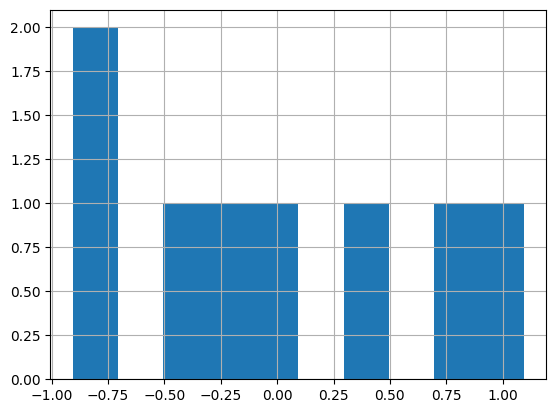

In [62]:
df["y-ypred"].hist()

# Actividad de consulta práctica hasta las 7:40 pm:

1. Calcular el error absoluto total y el MAE (error absoluto medio). Ayuda: usar el df y extenderlo como se hizo para el cuadratico.

2. MAPE

3. Otras métricas: R2, entre otras.

*Recuerden:

Replicar lo anterior en cada dataset (el del video de youtube, el de las ventas y reg mutiple del link donde está la formula del OLS, y si alcanzan pueden ir replicando en su datset del caso de estudio)


In [ ]:
#sacar el valor absoluto , pon una columna para error absoluto, lo sumo y lo divido entre 8, calcule r2

In [70]:
df["absolute_error"]=abs(df["y-ypred"])
df

,x,y,ypred,y-ypred,error^2,absolute_error
0,1,2,2.358491,-0.358491,0.128515,0.358491
1,2,3,3.207547,-0.207547,0.043076,0.207547
2,2,4,3.207547,0.792453,0.627981,0.792453
3,3,4,4.056604,-0.056604,0.003204,0.056604
4,4,4,4.905660,-0.905660,0.820221,0.905660
5,4,6,4.905660,1.094340,1.197579,1.094340
6,5,5,5.754717,-0.754717,0.569598,0.754717
7,6,7,6.603774,0.396226,0.156995,0.396226


In [74]:
print("MAPE:", mape, "%")

MAPE: 13.463050314465425 %
